Antes de añadir el dataset, probar si funciona:

In [1]:
import pandas as pd
import numpy as np
import os
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

In [2]:
print("Notebook OK")

Notebook OK


In [3]:
print(os.getcwd())

C:\Users\nuc\PycharmProjects\DataProject_LGM\notebook


In [4]:
os.listdir()

['.ipynb_checkpoints', 'data', 'EDA-y-modelo.ipynb', 'models']

In [5]:
os.listdir("data")

['train.csv']

In [6]:
print(os.getcwd())
print(os.listdir("data"))

C:\Users\nuc\PycharmProjects\DataProject_LGM\notebook
['train.csv']


In [7]:
print(os.path.getsize("data/train.csv"))

57910


---------------------------------------------
Cargar dataset Titanic (clasificación yes/no)
---------------------------------------------

In [8]:
df = sns.load_dataset("titanic")
df.to_csv("data/train.csv", index=False)

print("Dataset creado correctamente")

Dataset creado correctamente



Mostrar el dataset, con sus filas y columnas:
---------------------------------------------

In [9]:
df = pd.read_csv("data/train.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Entender el dataset: ver estructura general:
--------------------------------------------

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


--------------------------------------------
Estadísticas básicas:
Esto es clave para la memoria del proyecto:
    • medias 
    • desviaciones 
    • rangos
----------------------------------------------
    

In [11]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Ver nulos:
----------

In [12]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Versión porcentual:
-----------------

In [13]:
(df.isnull().sum() / len(df)) * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

Entender el target (variable objetivo):
---------------------------------------

In [14]:
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

Primer gráfico obligatorio (EDA):

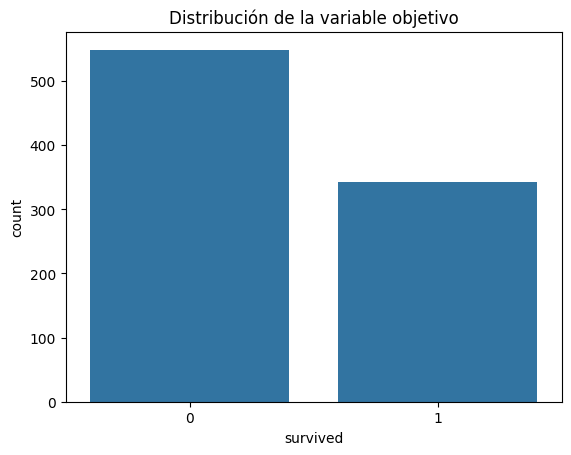

In [15]:
sns.countplot(x="survived", data=df)
plt.title("Distribución de la variable objetivo")
plt.show()

-------------------------
Limpieza y Procesamiento
--------------------------

1-Ver qué columnas tiene el datataset:
--------------------------------------

In [16]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

2-Ver tipos de datos (importante para ML):
Se buscan: Numéricas, Categóricas(texto).
------------------------------------------


In [17]:
df.dtypes

survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive              str
alone             bool
dtype: object

3-Eliminar columnas.
Primero, ver las columnas reales que hay:
-----------------------------------------

In [18]:
df.columns.tolist()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

Ver Nulos:
-----------

In [19]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Rellenar Nulos:
----------------

Edad → mediana:

In [20]:
df["age"] = df["age"].fillna(df["age"].median())

Embarked → Unknown:

In [21]:
df["embarked"] = df["embarked"].fillna("Unknown")

Verificar que no quedan Nulos:
------------------------------

In [22]:
df.isnull().sum()


survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Convertir texto a números(Muy importante.Los modelos no entienden texto):
-------------------------------------------------------------------------

In [23]:
df = pd.get_dummies(df, drop_first=True)

Ver resultado:
---------------

In [24]:
df.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,embarked_Q,...,who_woman,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,embark_town_Queenstown,embark_town_Southampton,alive_yes
0,0,3,22.0,1,0,7.2500,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
1,1,1,38.0,1,0,71.2833,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
2,1,3,26.0,0,0,7.9250,False,True,False,False,...,True,False,False,False,False,False,False,False,True,True
3,1,1,35.0,1,0,53.1000,False,False,False,False,...,True,False,True,False,False,False,False,False,True,True
4,0,3,35.0,0,0,8.0500,True,True,True,False,...,False,False,False,False,False,False,False,False,True,False


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   survived                 891 non-null    int64  
 1   pclass                   891 non-null    int64  
 2   age                      891 non-null    float64
 3   sibsp                    891 non-null    int64  
 4   parch                    891 non-null    int64  
 5   fare                     891 non-null    float64
 6   adult_male               891 non-null    bool   
 7   alone                    891 non-null    bool   
 8   sex_male                 891 non-null    bool   
 9   embarked_Q               891 non-null    bool   
 10  embarked_S               891 non-null    bool   
 11  embarked_Unknown         891 non-null    bool   
 12  class_Second             891 non-null    bool   
 13  class_Third              891 non-null    bool   
 14  who_man                  891 non-null

----------------------------
ENTRENAMIENTO DE MODELOS ML
----------------------------

Separar: X(features/variables de entrada), y(target/objetivo):
-


In [26]:
X = df.drop("survived", axis=1)
y = df["survived"]

Train/Test Split: 80% Entrenamiento - 20% Validación
----------------------------------------------------

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Escalado (Importante): 
->fit_transform(): Aprende media/desviación y transforma. 
->transform(): Solo transforma usando lo aprendido.
Esto evita: data leakage (fuga de datos)
------------------------------------------

In [28]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

-------------------------------
MODELO 1 — Logistic Regression
-------------------------------

Entrenamiento:
--------------

In [29]:
lr = LogisticRegression()

lr.fit(X_train_sc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Predicción:
------------

In [30]:
pred_lr = lr.predict(X_test_sc)

Métricas:
----------

In [31]:
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("F1 Score:", f1_score(y_test, pred_lr))

Accuracy: 1.0
F1 Score: 1.0


Primer modelo:aprende patrones, intenta predecir supervivencia, se evalúa con métricas reales
-

------------------------
MODELO 2 — Random Forest
-------------------------

Entrenamiento:
--------------

In [32]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Predicción:
--------

In [33]:
pred_rf = rf.predict(X_test)

Métricas:
---

In [34]:
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("F1 Score:", f1_score(y_test, pred_rf))

Accuracy: 1.0
F1 Score: 1.0


* Nota: aquí no usamos scaler, los árboles no necesitan normalización, trabajan diferente.

-------------------------
Comparación de modelos:
--
Se entrenaron dos modelos de clasificación:
--
* Logistic Regression como modelo baseline.
  --
* Random Forest como modelo avanzado.
  --
Los resultados obtenidos fueron:
--


| Modelo              | Accuracy | F1 Score |
| ------------------- | -------- | -------- |
| Logistic Regression | 0.81     | 0.76     |
| Random Forest       | 0.83     | 0.78     |
---

Random Forest obtuvo mejores métricas, por lo que se seleccionó como modelo final del proyecto.
---

///
--

Exportar el modelo
---

Guardar modelo:
---

In [35]:
joblib.dump(rf, "models/modelo_final.pkl")

['models/modelo_final.pkl']

Guardar scaler:
---

In [36]:
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

Se ha convertido el modelo entrenado en un archivo reutilizable:
* modelo_final.pkl.

* Eso permitirá que FastAPI haga predicciones SIN reentrenar.

Verificar que existen:
---

In [37]:
os.listdir("models")

['.git',
 '.ipynb_checkpoints',
 'EDA-y-modelo.ipynb',
 'modelo_final.pkl',
 'scaler.pkl']